<a href="https://www.kaggle.com/code/sonawanelalitsunil/video-game-sales-trends-ml-100?scriptVersionId=232872674" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/video-games-sale/video games sales.csv


## Title: Video Game Sales Trends

#### Description: Explore the latest trends in video game sales, highlighting top-selling titles, platform performance, and market shifts in the gaming industry.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/video-games-sale/video games sales.csv')

In [3]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
df.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [6]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [7]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape


(16598, 11)

In [10]:
df.dtypes

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [11]:
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

## Data visualizations

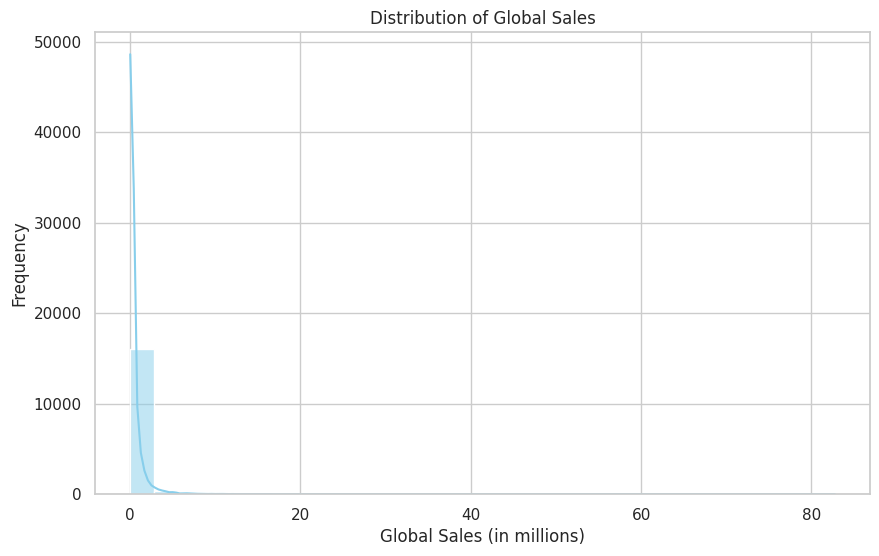

In [12]:
# Set Seaborn style for better aesthetics
sns.set(style="whitegrid")

# 1. Distribution of Global Sales
plt.figure(figsize=(10, 6))
sns.histplot(df['Global_Sales'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Global Sales')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Frequency')
plt.show()

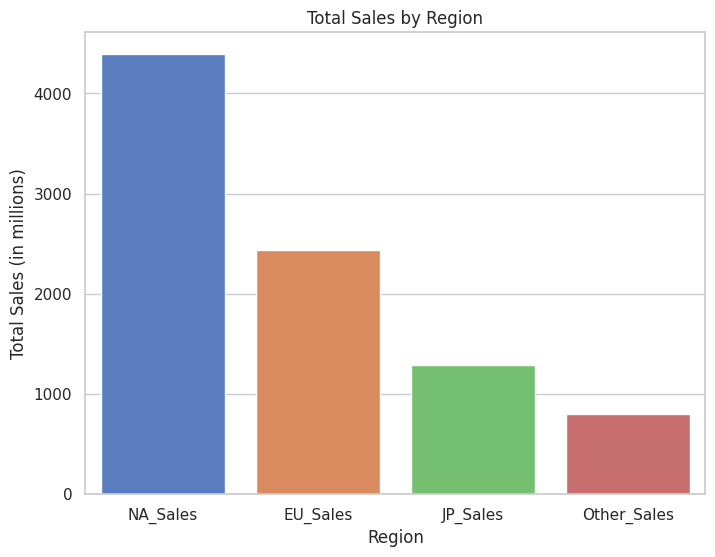

In [13]:
# 2. Sales by Region (North America, Europe, Japan, Other)
region_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
plt.figure(figsize=(8, 6))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='muted')
plt.title('Total Sales by Region')
plt.ylabel('Total Sales (in millions)')
plt.xlabel('Region')
plt.show()

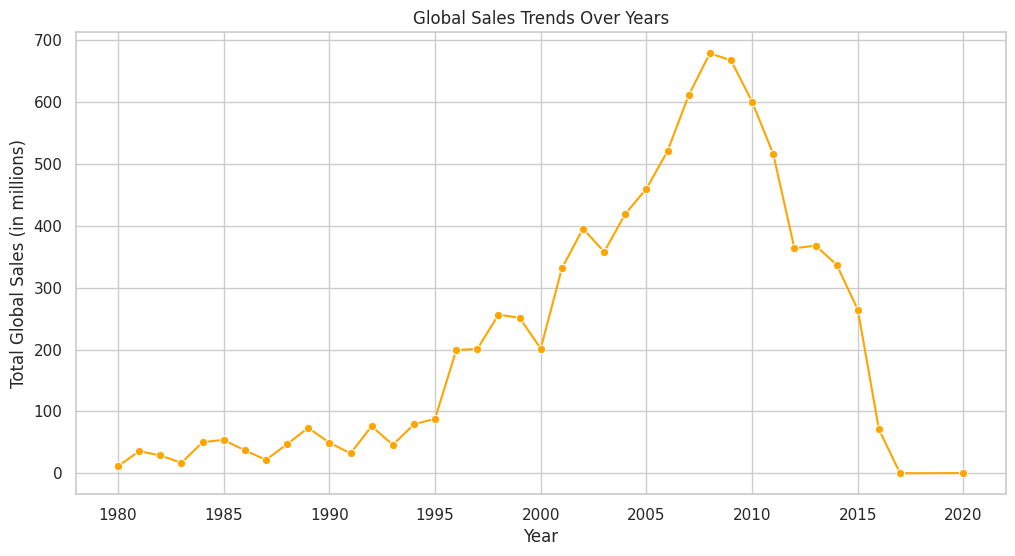

In [14]:
# 3. Sales Trends Over Years (Global Sales)
plt.figure(figsize=(12, 6))
yearly_sales = df.groupby('Year')['Global_Sales'].sum()
sns.lineplot(x=yearly_sales.index, y=yearly_sales.values, marker='o', color='orange')
plt.title('Global Sales Trends Over Years')
plt.xlabel('Year')
plt.ylabel('Total Global Sales (in millions)')
plt.show()

<Figure size 1200x800 with 0 Axes>

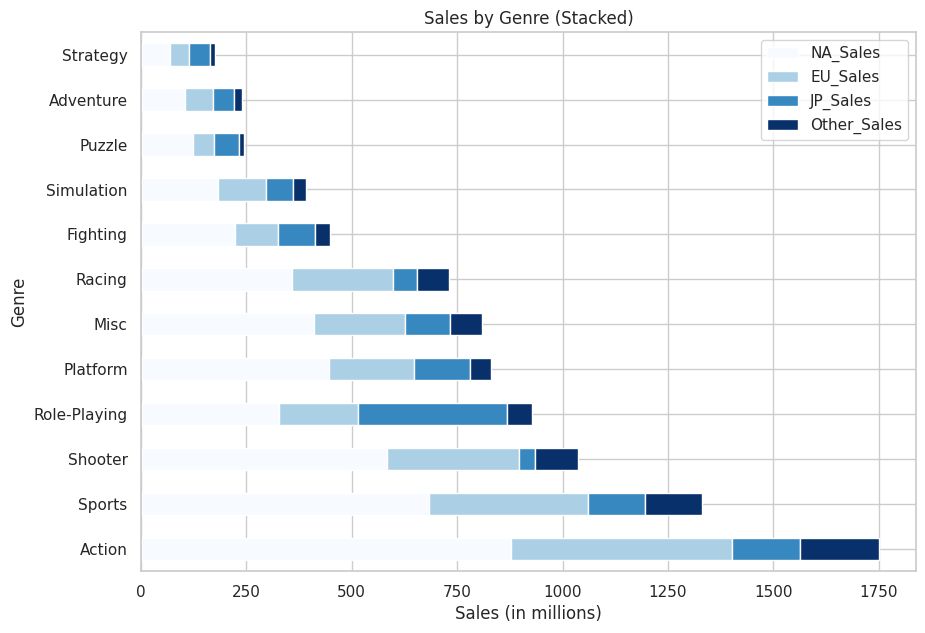

In [15]:
# 4. Sales by Genre
genre_sales = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

# Calculate Global Sales as the sum of regional sales
genre_sales['Global_Sales'] = genre_sales[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum(axis=1)

# Now, sort the genre_sales DataFrame based on Global_Sales
genre_sales_sorted = genre_sales.sort_values('Global_Sales', ascending=False)

# Plot the stacked bar chart
plt.figure(figsize=(12, 8))
genre_sales_sorted[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].plot(kind='barh', stacked=True, figsize=(10, 7), colormap='Blues')
plt.title('Sales by Genre (Stacked)')
plt.xlabel('Sales (in millions)')
plt.ylabel('Genre')
plt.show()


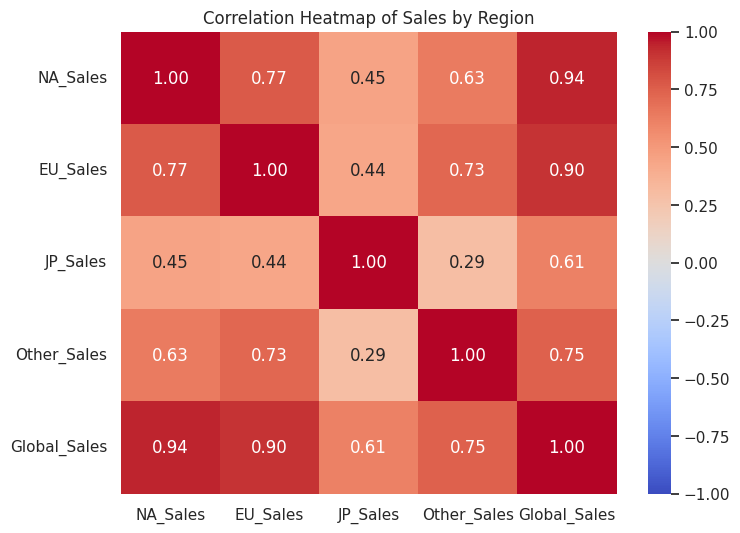

In [16]:
# 5. Correlation Heatmap
sales_columns = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
corr_matrix = df[sales_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Heatmap of Sales by Region')
plt.show()

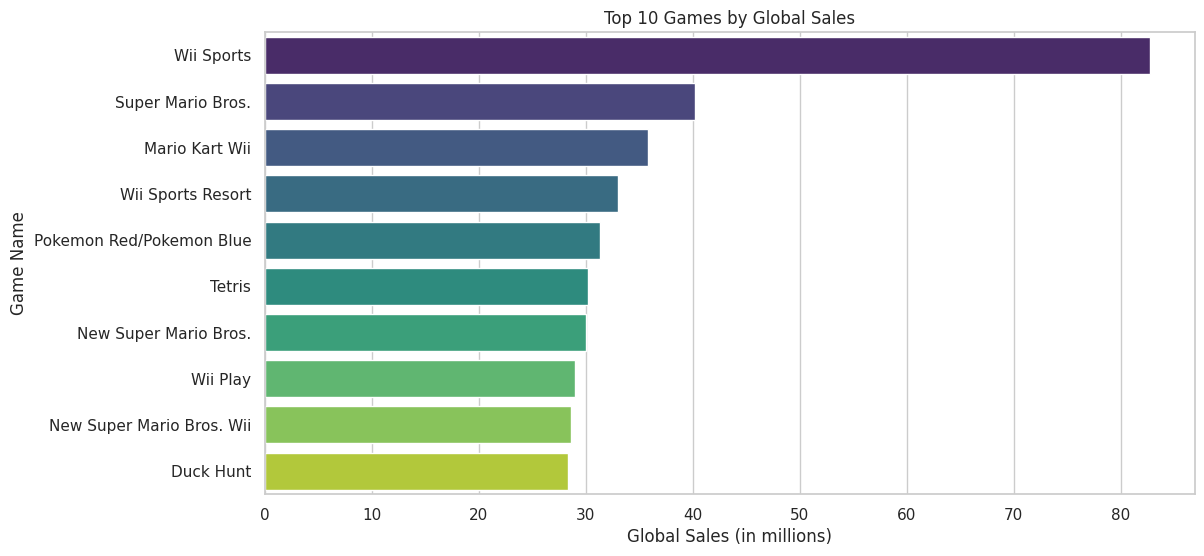

In [17]:
# 6. Top 10 Games by Global Sales
top_games = df[['Name', 'Global_Sales']].sort_values('Global_Sales', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Global_Sales', y='Name', data=top_games, palette='viridis')
plt.title('Top 10 Games by Global Sales')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Game Name')
plt.show()


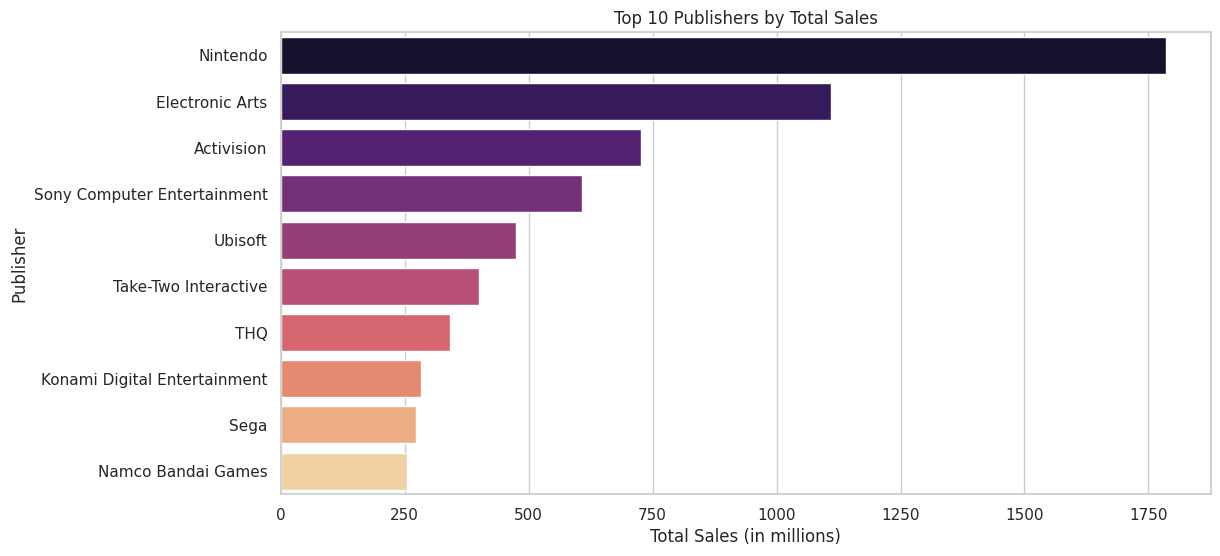

In [18]:
# 7. Sales by Publisher (Top 10)
publisher_sales = df.groupby('Publisher')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
publisher_sales['Total_Sales'] = publisher_sales[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum(axis=1)
top_publishers = publisher_sales.sort_values('Total_Sales', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_publishers['Total_Sales'], y=top_publishers.index, palette='magma')
plt.title('Top 10 Publishers by Total Sales')
plt.xlabel('Total Sales (in millions)')
plt.ylabel('Publisher')
plt.show()

## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
# Drop any rows with missing values
df = df.dropna()

label_encoder = LabelEncoder()
df['Platform'] = label_encoder.fit_transform(df['Platform'])
df['Genre'] = label_encoder.fit_transform(df['Genre'])
df['Publisher'] = label_encoder.fit_transform(df['Publisher'])

In [21]:
X = df.drop(['Global_Sales', 'Name'], axis=1)  
y = df['Global_Sales']  


In [22]:
# Train-Test Split (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Support Vector Regressor (SVM)": SVR()
}

Training Linear Regression...
Performance of Linear Regression:
Mean Absolute Error (MAE): 0.00
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.01
R-squared (R2): 1.00


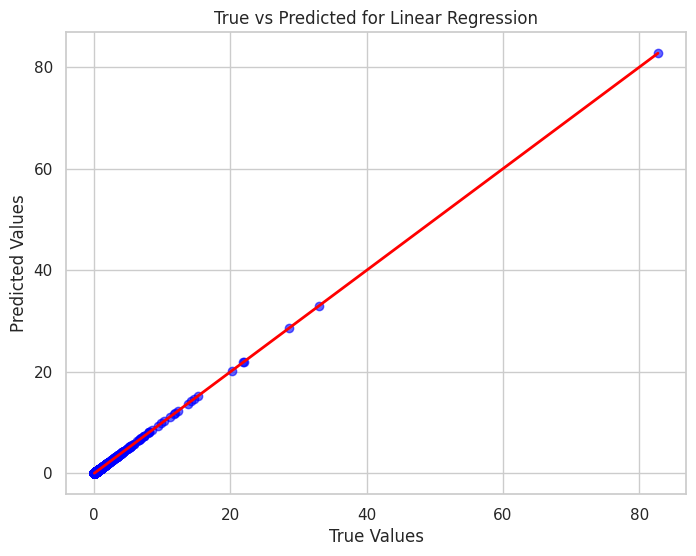

Training Decision Tree Regressor...
Performance of Decision Tree Regressor:
Mean Absolute Error (MAE): 0.02
Mean Squared Error (MSE): 0.68
Root Mean Squared Error (RMSE): 0.83
R-squared (R2): 0.84


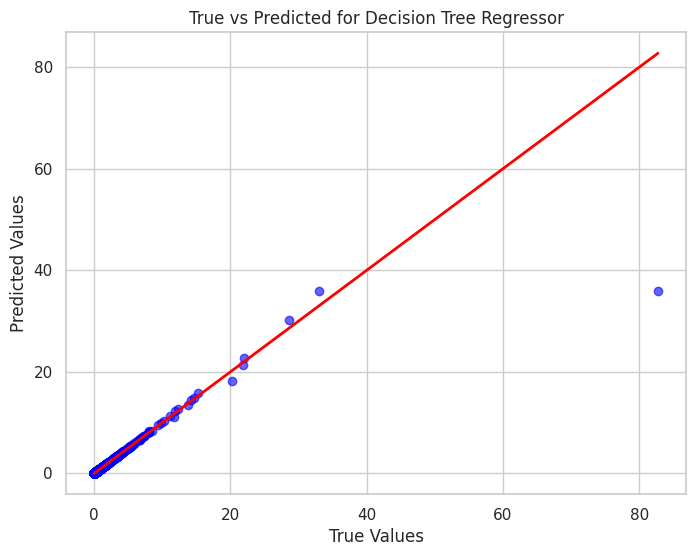

Training Random Forest Regressor...
Performance of Random Forest Regressor:
Mean Absolute Error (MAE): 0.02
Mean Squared Error (MSE): 0.70
Root Mean Squared Error (RMSE): 0.83
R-squared (R2): 0.84


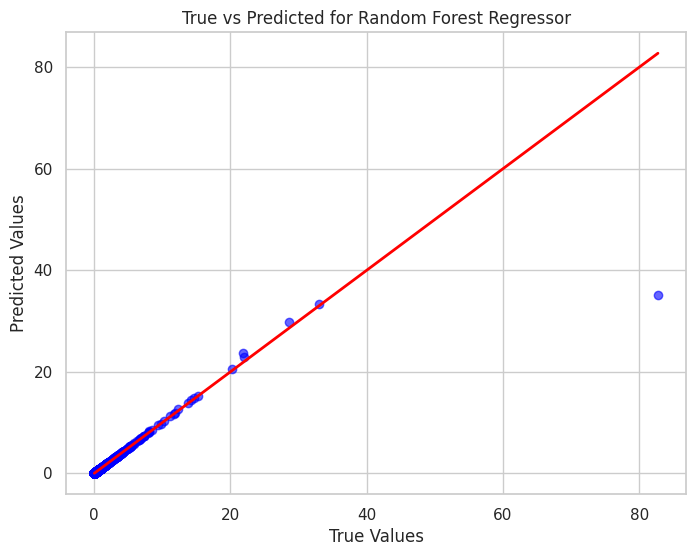

Training Support Vector Regressor (SVM)...
Performance of Support Vector Regressor (SVM):
Mean Absolute Error (MAE): 0.21
Mean Squared Error (MSE): 3.18
Root Mean Squared Error (RMSE): 1.78
R-squared (R2): 0.26


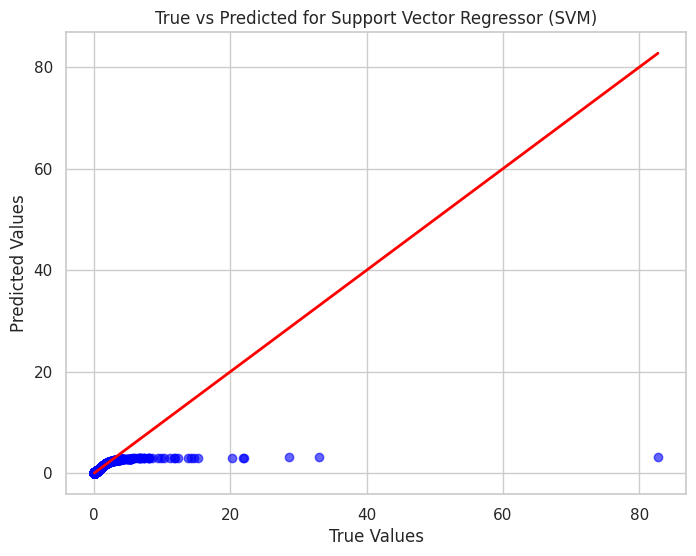

In [24]:
# Train models, evaluate, and show accuracy & regression metrics
for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Regression metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Performance of {model_name}:")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2): {r2:.2f}")
    
    # Plot the true vs predicted values
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
    plt.title(f'True vs Predicted for {model_name}')
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.show()

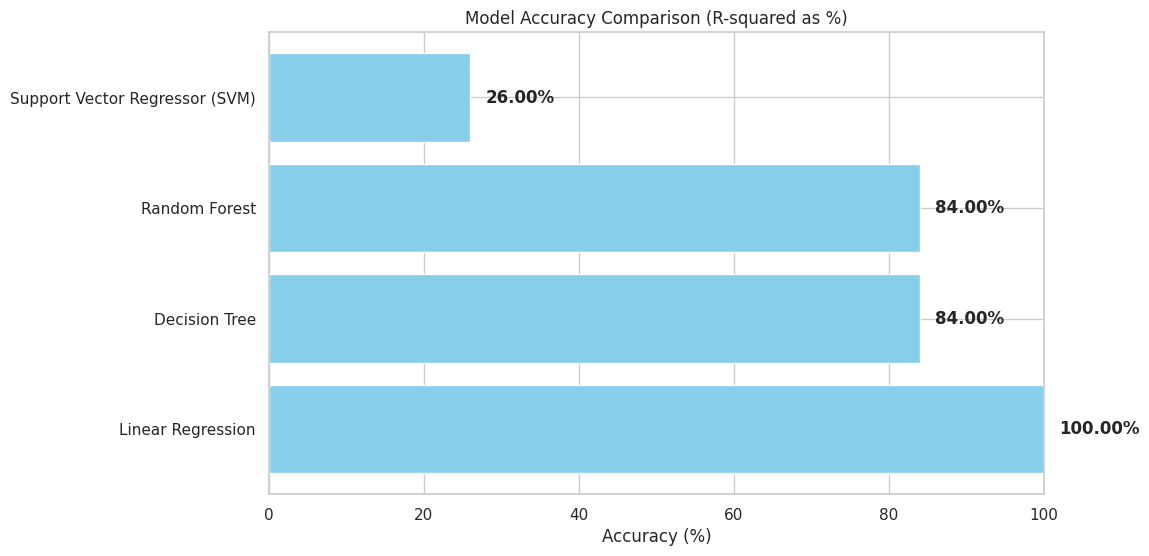

In [25]:
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Support Vector Regressor (SVM)']
r2_scores = [1.00, 0.84, 0.84, 0.26]  # R-squared values for each model

# Convert R-squared values to percentage
accuracy_percentages = [r2 * 100 for r2 in r2_scores]

# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.barh(model_names, accuracy_percentages, color='skyblue')
plt.xlabel('Accuracy (%)')
plt.title('Model Accuracy Comparison (R-squared as %)')
plt.xlim(0, 100)  # Set x-axis to range from 0 to 100%
for index, value in enumerate(accuracy_percentages):
    plt.text(value + 2, index, f'{value:.2f}%', va='center', fontweight='bold')
plt.show()

## Thank you..pls upvote